In [39]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import requests

%matplotlib inline 

In [2]:
def download(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open (filename, 'w', encoding='utf-8') as f:
            f.write(response.text)
    else:
        print('Download failed: ', response.status_code)

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv"
filename = "cars_model.csv"

download(url, filename)

df = pd.read_csv(filename)

# 🔢 Linear Regression: Understanding the Core Concept

In [3]:
lm = LinearRegression()
lm

LinearRegression()

## How Could "Highway-MPG" Help Us Predict Car Price?

We use **Simple Linear Regression** to see how `highway-mpg` affects `price`.

- **Predictor:** `highway-mpg` (fuel efficiency on highways)  
- **Response:** `price` (car market value)

In [4]:
x = df[['highway-mpg']]
y = df[['price']]

lm.fit(x, y)

LinearRegression()

In [5]:
yhat = lm.predict(x)
yhat[0:5]

array([[16236.50464347],
       [16236.50464347],
       [17058.23802179],
       [13771.3045085 ],
       [20345.17153508]])

## What is the value of the slope (coefficient) (a)?

In [6]:
a = lm.coef_[0][0]
a

-821.733378321925

## What is the value of the intercept (b)?

In [7]:
b = lm.intercept_[0]
b

38423.305858157386

## What is the final estimated linear model we get?

In [8]:
print(f'yhat = {a:.2f}x + {b:.2f}')

yhat = -821.73x + 38423.31


## 🔍 Linear Regression Between Engine Size and Price

In this analysis, we explore the **relationship between a car’s engine size and its price** using a **Simple Linear Regression** model.

- **Predictor (X):** `engine-size` — represents the size or capacity of the engine.  
- **Response (Y):** `price` — represents the car’s market price.

In [9]:
lm = LinearRegression()

x = df[['engine-size']]
y = df[['price']]
lm.fit(x, y)

yhat = lm.predict(x)
a = lm.coef_[0][0]
b = lm.intercept_[0]

print("=====Linear Regression between Engine-size & Price=====")
print(f'yhat = {a:.2f}x + {b:.2f}')

=====Linear Regression between Engine-size & Price=====
yhat = 166.86x + -7963.34


## 🚗 Multiple Linear Regression

In this section, we extend simple linear regression to **Multiple Linear Regression**,  
where we use **two or more predictor variables** to predict the target variable.

The general equation is:

**yhat = a_1x + a_2x + a_3x + ... + a_n + b**

From previous analysis, we found several strong predictors of car price:
- `horsepower`
- `curb-weight`
- `engine-size`
- `highway-mpg`

We’ll now build a regression model using these variables as predictors to estimate **car price**.

In [10]:
lm = LinearRegression()
x = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
y = df[['price']]
lm.fit(x, y)

features = x.columns
equation = f"yhat = {lm.intercept_[0]:.2f}"
for coef, feat in zip(lm.coef_[0], features):
    equation += f" + ({coef:.2f} × {feat})"

print(equation)

yhat = -15806.62 + (53.50 × horsepower) + (4.71 × curb-weight) + (81.53 × engine-size) + (36.06 × highway-mpg)


## 📈 Regression Plot

For **Simple Linear Regression**, one of the best ways to visualize the model fit is by using a **regression plot**.

This plot combines:
- A **scatterplot** of the actual data points, and  
- The **fitted regression line** going through them.

It helps us visually estimate:
- The **relationship** between the two variables,  
- The **strength** of the correlation, and  
- The **direction** (positive or negative).

Let's visualize how **highway-mpg** can act as a potential predictor variable for **price**.

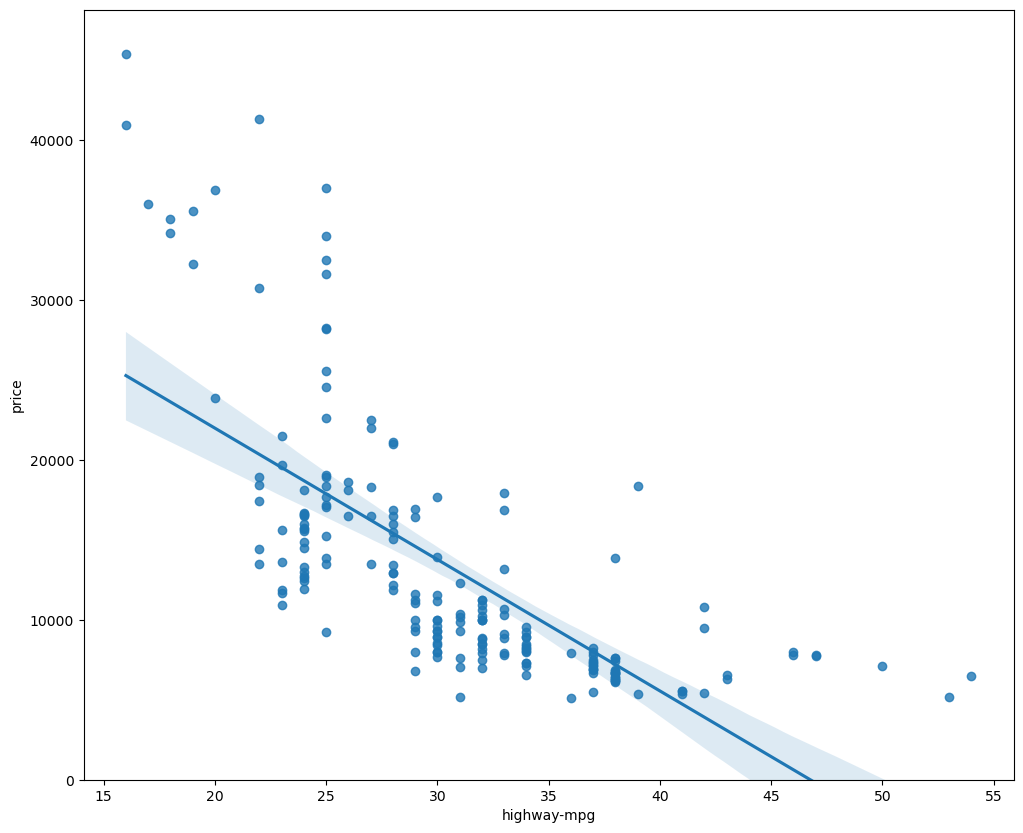

In [11]:
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.regplot(x='highway-mpg', y='price', data=df)
plt.ylim(0,)
plt.show()

# We can see from this plot that price is negatively correlated to highway-mpg since the regression slope 
# is negative.

Let's compare this plot to the regression plot of **"peak-rpm"**.

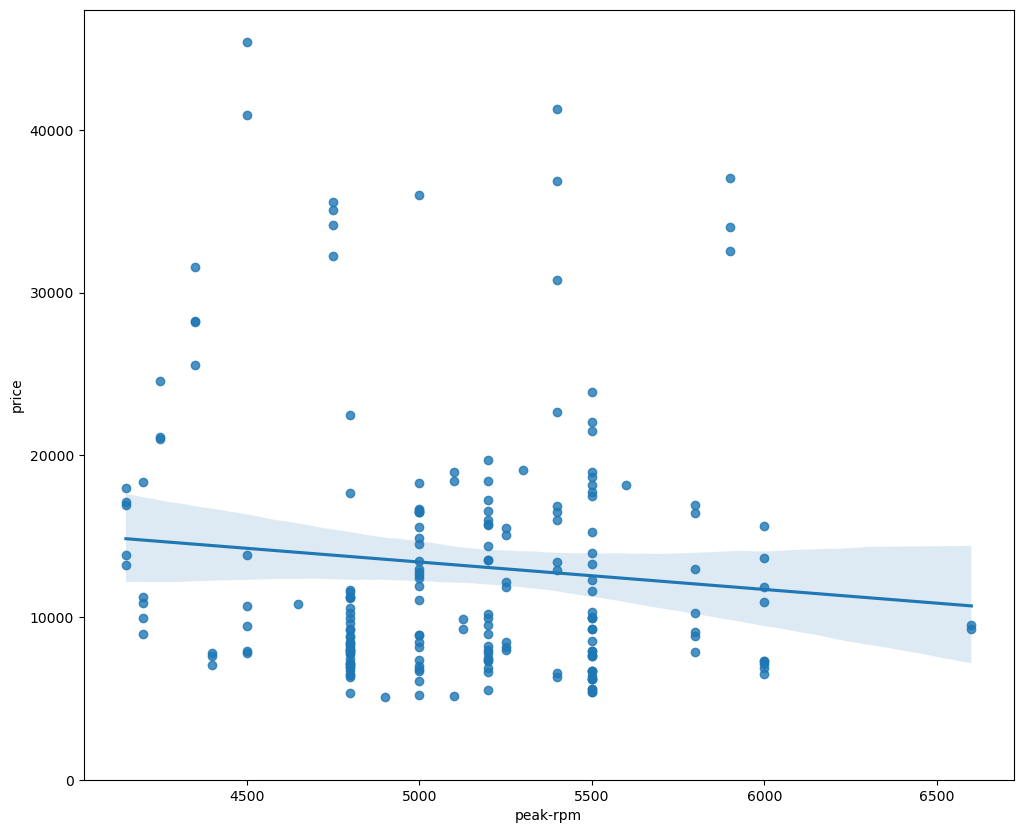

In [12]:
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.regplot(x='peak-rpm', y='price', data=df)
plt.ylim(0,)
plt.show()

Given the regression plots above, is **"peak-rpm"** or **"highway-mpg"** more strongly correlated with **"price"**?

Hint: Use **corr()** function to verify the answer

In [13]:
correlation = df[["highway-mpg", "peak-rpm", "price"]].corr()
print(correlation)

# 	           highway-mpg	 peak-rpm	   price
# highway-mpg	1.000000	-0.058598	-0.704692
# peak-rpm	   -0.058598	 1.000000	-0.101616
# price	       -0.704692	-0.101616	 1.000000

print("=> Highway-mpg is a lot more strongly correlated with Price than Peak-rpm")

             highway-mpg  peak-rpm     price
highway-mpg     1.000000 -0.058598 -0.704692
peak-rpm       -0.058598  1.000000 -0.101616
price          -0.704692 -0.101616  1.000000
=> Highway-mpg is a lot more strongly correlated with Price than Peak-rpm


## Residual Plot

A good way to visualize the variance of the data is to use a **residual plot**.

### What is a residual?
The difference between the observed value (**y**) and the predicted value (**ŷ**) is called the **residual (e)**.


**e = y - yhat**


When we look at a regression plot, the residual is the distance from the data point to the fitted regression line.

---

### What is a residual plot?
A **residual plot** is a graph that shows:
- The **residuals** on the vertical (**y**) axis  
- The **independent variable** on the horizontal (**x**) axis  

It helps us visualize how far off our predictions are across the range of input values.

---

### What do we look for in a residual plot?
We mainly look at the **spread of the residuals**:

- ✅ **Randomly spread out residuals around the x-axis** → The linear model is appropriate.  
- ⚠️ **Patterns or systematic shapes (e.g., curves)** → The linear model may not fit the data well.

---

### Why does this matter?
Randomly distributed residuals indicate that:
- The **variance is constant** (homoscedasticity)
- The **linear assumption** holds  
→ Therefore, a **linear regression model** is a good fit for this data.


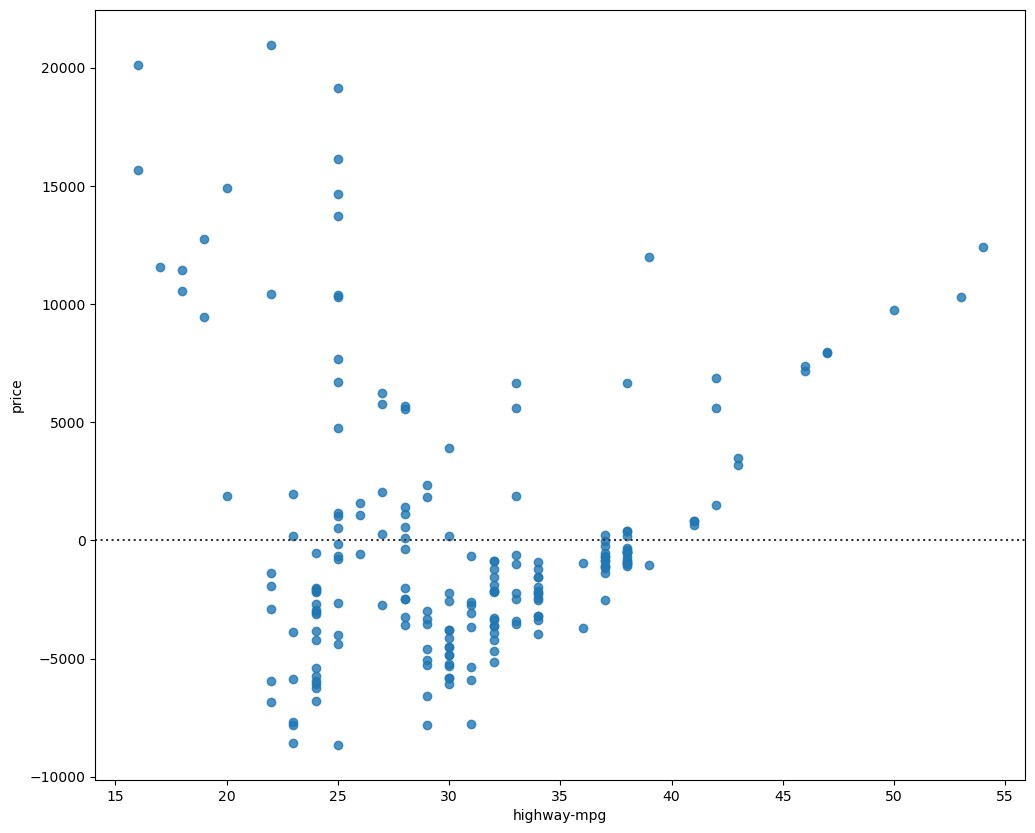

=> From the residual plot, we can see that the residuals are not randomly distributed around the x-axis.
=> This indicates that the linear regression model does not fully capture the relationship between the variables.
=> Therefore, a non-linear model may be more appropriate to represent the data more accurately.


In [14]:
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.residplot(x=df['highway-mpg'], y=df['price'])
plt.show()

print("=> From the residual plot, we can see that the residuals are not randomly distributed around the x-axis.")
print("=> This indicates that the linear regression model does not fully capture the relationship between the variables.")
print("=> Therefore, a non-linear model may be more appropriate to represent the data more accurately.")

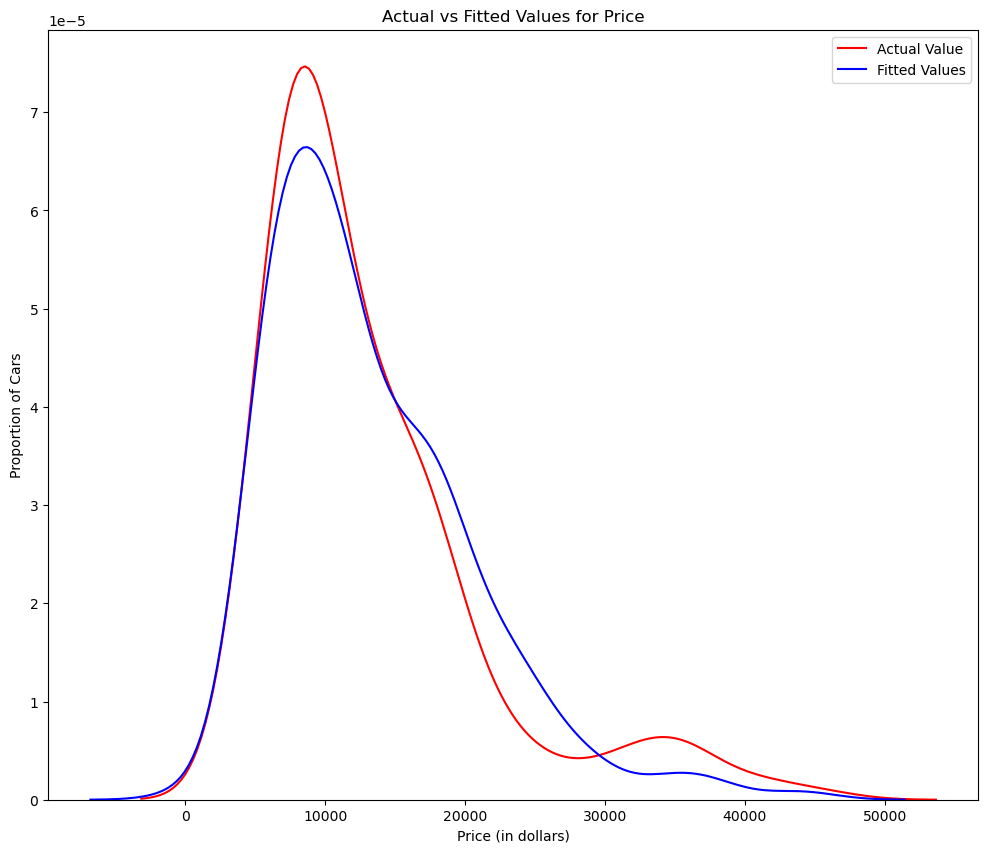

In [15]:
Z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
Y_hat = lm.predict(Z)

plt.figure(figsize=(12, 10))
ax = plt.gca()

sns.kdeplot(df['price'], color="r", label="Actual Value", ax=ax)
sns.kdeplot(Y_hat.flatten(), color="b", label="Fitted Values", ax=ax)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')
plt.legend()
plt.show()

## 3. Polynomial Regression and Pipelines

Polynomial regression is a special case of the general linear regression or multiple linear regression models.  
We use it to model **non-linear relationships** by adding higher-order terms (squared, cubic, etc.) of the predictor variables.

### 🔹 Types of Polynomial Regression:
- **Quadratic** – 2nd order  
- **Cubic** – 3rd order  
- **Higher-order** – 4th, 5th, etc.

Basically, instead of fitting a straight line, polynomial regression lets us fit **curved relationships** between the independent and dependent variables.

---

### 🧠 Example: Fitting a Polynomial Model

Earlier, we saw that a simple linear regression using `highway-mpg` didn’t fit the data well.  
Let’s now try a **polynomial model** to improve the fit.

In [16]:
def PlotPolly(model, independent_variable, dependent_variable, name):
    x_new = np.linspace(15, 55, 100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variable, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit with Matplotlib for Price ~ Length')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(name)
    plt.ylabel('Price of Cars')

    plt.show()
    plt.close()

In [17]:
x = df['highway-mpg']
y = df['price']

# Create 3 order polynomial model with the variables x and y from above.
f = np.polyfit(x, y, 3)
p = np.poly1d(f)

print('The coefficients (abcd) are: ', np.polyfit(x, y, 3))
print('The expression: ', p)

The coefficients (abcd) are:  [-1.55663829e+00  2.04754306e+02 -8.96543312e+03  1.37923594e+05]
The expression:          3         2
-1.557 x + 204.8 x - 8965 x + 1.379e+05


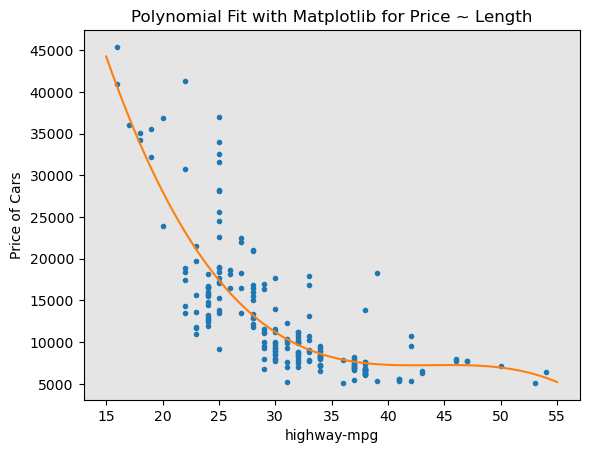

In [18]:
PlotPolly(p, x, y, 'highway-mpg')

            11             10             9           8         7
-1.243e-08 x  + 4.722e-06 x  - 0.0008028 x + 0.08056 x - 5.297 x
          6        5             4             3             2
 + 239.5 x - 7588 x + 1.684e+05 x - 2.565e+06 x + 2.551e+07 x - 1.491e+08 x + 3.879e+08


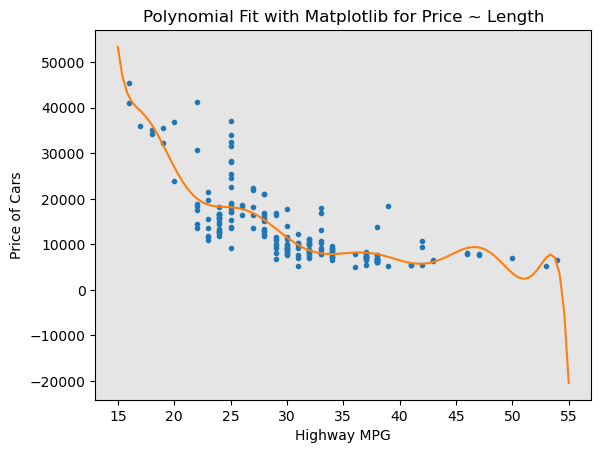

In [19]:
# Experiment: Create 11 order polynomial model with the variables x and y from above.
f1 = np.polyfit(x, y, 11)
p1 = np.poly1d(f1)

print(p1)
PlotPolly(p1,x,y, 'Highway MPG')

In [20]:
from sklearn.preprocessing import PolynomialFeatures

In [21]:
pr=PolynomialFeatures(degree=2)
pr

PolynomialFeatures()

In [22]:
Z_pr=pr.fit_transform(Z)

In [23]:
Z.shape

(201, 4)

In [24]:
Z_pr.shape

(201, 15)

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [26]:
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model',LinearRegression())]

In [27]:
pipe=Pipeline(Input)
pipe

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [28]:
Z = Z.astype(float)
pipe.fit(Z,y)

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [29]:
ypipe=pipe.predict(Z)
ypipe[0:4]

array([13102.74784201, 13102.74784201, 18225.54572197, 10390.29636555])

In [30]:
# Create a pipeline that standardizes the data, then produce a prediction using a linear regression 
# model using the features Z and target y.

Input=[('scale',StandardScaler()),('model',LinearRegression())]

pipe=Pipeline(Input)

pipe.fit(Z,y)

ypipe=pipe.predict(Z)
ypipe[0:10]

array([13699.11161184, 13699.11161184, 19051.65470233, 10620.36193015,
       15521.31420211, 13869.66673213, 15456.16196732, 15974.00907672,
       17612.35917161, 10722.32509097])

## 4. Measures for In-Sample Evaluation

When evaluating our models, not only do we want to visualize the results, but we also want a **quantitative measure** to determine how accurate the model is.

Two very important measures that are often used in statistics to determine the accuracy of a model are:

- **R² / R-squared**
- **Mean Squared Error (MSE)**

---

### 🔹 R-squared (Coefficient of Determination)

**R-squared**, also known as the *coefficient of determination*, measures how close the data points are to the fitted regression line.

It represents the **percentage of variation in the dependent variable (y)** that can be explained by the independent variable(s) in the model.

Mathematically:

R² = 1 − (Σ(yᵢ − ŷᵢ)²) / (Σ(yᵢ − ȳ)²)

Where:
- \( y_i \): actual value  
- \( \hat{y}_i \): predicted value  
- \( \bar{y} \): mean of actual values  

👉 A higher R² value (closer to 1) indicates that the model fits the data better.

---

### 🔹 Mean Squared Error (MSE)

**Mean Squared Error (MSE)** measures the *average of the squares of the errors* — that is, the average squared difference between the actual value (\(y\)) and the predicted value (\(\hat{y}\)).

MSE = (1 / n) × Σ(yᵢ − ŷᵢ)²

Lower MSE means the model's predictions are closer to the actual data.

---

### 🧠 Summary

| Metric | Measures | Ideal Value | Meaning |
|:-------|:----------|:-------------|:---------|
| **R²** | Goodness of fit | Closer to 1 | Model explains more variance |
| **MSE** | Average squared error | Closer to 0 | Smaller prediction errors |

---

## Model 1: Simple Linear Regression

**Calculate R^2**

In [31]:
# highway_mpg_fit

X = df[['highway-mpg']]
Y = df[['price']]

lm.fit(X, Y)
# Find the R^2
print('The R-square is: ', lm.score(X, Y))

The R-square is:  0.4965911884339175


**Predict the values**

In [32]:
Yhat=lm.predict(X)
print('The output of the first four predicted value is:\n', Yhat[0:4])

The output of the first four predicted value is:
 [[16236.50464347]
 [16236.50464347]
 [17058.23802179]
 [13771.3045085 ]]


**Calculate MSE between the price and predicted value**

In [ ]:
mse = mean_squared_error(df['price'], Yhat)
print('The mean square error of price and the predicted value is: ', mse)

# The smaller the MSE, the better the model

The mean square error of price and the predicted value is:  31635042.944639895


## Model 2: Multiple Linear Regression

**Calculate R^2**

In [ ]:
Z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]

# fit the model 
lm.fit(Z, df['price'])

# Find the R^2
print('The R-square is: ', lm.score(Z, df['price']))

# We can say that ~80.896 % of the variation of price is explained by this multiple linear regression

The R-square is:  0.8093562806577457


**Predict the values**

In [37]:
Y_predict_multifit = lm.predict(Z)
print('The output of the first four predicted value is:\n', Y_predict_multifit[0:4])

The output of the first four predicted value is:
 [13699.11161184 13699.11161184 19051.65470233 10620.36193015]


**Calculate MSE between the price and predicted value**

In [38]:
mse_multifit = mean_squared_error(df['price'], Y_predict_multifit)
print('The mean square error of price and the predicted value is: ', mse_multifit)


The mean square error of price and the predicted value is:  11980366.870726496


## Model 3: Polynomial Fit

**Calculate the R^2**

In [ ]:
r_squared = r2_score(y, p(x))
print('The R-square value is: ', r_squared)

# We can say that ~67.419 % of the variation of price is explained by this polynomial fit.

The R-square value is:  0.6741946663906515


**Calculate MSE between the price and predicted value**

In [42]:
mse_poly = mean_squared_error(df['price'], p(x))
print('The mean square error of price and predicted value is: ', mse_poly)

The mean square error of price and predicted value is:  20474146.426361237


## Prediction and Decision-Making

**After training the model using mothod fit(), predicting the targets using predict(), now using pyplot to visualize the result**

In [45]:
new_input = np.arange(1, 100, 1).reshape(-1, 1)

In [43]:
lm.fit(X, Y)
lm

LinearRegression()

In [46]:
yhat=lm.predict(new_input)
yhat[0:5]

d:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[37601.57247984],
       [36779.83910151],
       [35958.10572319],
       [35136.37234487],
       [34314.63896655]])

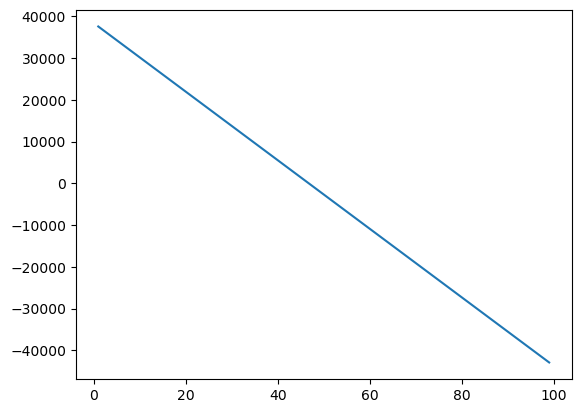

In [47]:
plt.plot(new_input, yhat)
plt.show()

Now that we have visualized the different models, and generated the R-squared and MSE values for the fits, how do we determine a good model fit?

* *What is a good R-squared value?*

When comparing models, **the model with the higher R-squared value is a better fit** for the data.

* *What is a good MSE?*

When comparing models, **the model with the smallest MSE value is a better fit** for the data.

#### Let's take a look at the values for the different models.

Simple Linear Regression: Using Highway-mpg as a Predictor Variable of Price.

* R-squared: 0.49659118843391759
* MSE: $3.16 \times 10^7$

Multiple Linear Regression: Using Horsepower, Curb-weight, Engine-size, and Highway-mpg as Predictor Variables of Price.

* R-squared: 0.80896354913783497
* MSE: $1.2 \times 10^7$

Polynomial Fit: Using Highway-mpg as a Predictor Variable of Price.

* R-squared: 0.6741946663906514
* MSE: $2.05 \times 10^7$

### 📈 Simple Linear Regression Model (SLR) vs Multiple Linear Regression Model (MLR)

Thông thường, càng có nhiều biến số, mô hình của bạn càng dự đoán tốt hơn, nhưng điều này không phải lúc nào cũng đúng. Đôi khi bạn có thể không có đủ dữ liệu, có thể gặp các vấn đề về số học, hoặc nhiều biến có thể không hữu ích và thậm chí hoạt động như **nhiễu** (noise). Do đó, bạn nên luôn kiểm tra **MSE** và **$R^2$**.

Để so sánh kết quả của mô hình MLR và SLR, chúng ta xem xét sự kết hợp của cả $R^2$ và MSE để đưa ra kết luận tốt nhất về độ phù hợp của mô hình.

* **MSE**: MSE của SLR là $3.16 \times 10^7$ trong khi MLR có MSE là $1.2 \times 10^7$. **MSE của MLR nhỏ hơn rất nhiều.**
* **$R^2$**: Trong trường hợp này, chúng ta cũng có thể thấy có sự khác biệt lớn giữa $R^2$ của SLR và $R^2$ của MLR. $R^2$ cho SLR ($\approx 0.497$) rất nhỏ so với $R^2$ cho MLR ($\approx 0.809$).

$R^2$ này kết hợp với MSE cho thấy **MLR có vẻ là mô hình phù hợp hơn** trong trường hợp này so với SLR.

---

### 📉 Simple Linear Model (SLR) vs. Polynomial Fit

* **MSE**: Chúng ta có thể thấy **Phù hợp Đa thức (Polynomial Fit) đã giảm MSE** xuống, vì MSE này ($2.05 \times 10^7$) nhỏ hơn so với MSE từ SLR ($3.16 \times 10^7$).
* **$R^2$**: $R^2$ cho Phù hợp Đa thức ($0.674$) lớn hơn $R^2$ cho SLR ($0.497$), vì vậy Phù hợp Đa thức cũng đã làm tăng $R^2$ lên khá nhiều.

Vì Phù hợp Đa thức mang lại **MSE thấp hơn** và **$R^2$ cao hơn**, chúng ta có thể kết luận rằng đây là **mô hình phù hợp tốt hơn** so với hồi quy tuyến tính đơn giản để dự đoán "price" với "highway-mpg" là biến dự đoán.

---

### 📊 Multiple Linear Regression (MLR) vs. Polynomial Fit

* **MSE**: MSE cho MLR ($1.2 \times 10^7$) **nhỏ hơn** MSE cho Phù hợp Đa thức ($2.05 \times 10^7$).
* **$R^2$**: $R^2$ cho MLR ($0.809$) cũng **lớn hơn nhiều** so với $R^2$ cho Phù hợp Đa thức ($0.674$).